# Gradient Descent

## Daftar Isi
1. Definisi
1. Model Persamaan
1. Dataset
 1. Membuat dataset
 1. Menampilkan data
 1. Visualisasi data
1. Sum of Squared Residual (SSR)
1. Fungsi Optimasi Parameter
1. Coding time
1. Tugas Praktikum 1
1. Referensi

# Definisi

Gradient Descent (GD) adalah sebuah algoritma optimasi yang umumnya digunakan untuk mengestimasi nilai parameter suatu fungsi. GD memanfaatkan pendekatan berbasis turunan parsial di mana nilai optimal dari parameter dicapai ketika nilai gradien mencapai konvergen. Konvergen adalah suatu dari kondisi di mana nilai eror, loss, gradien tidak lagi mengalami perubahan yang signifikan. 

# Model Persamaan

Pada kali ini, GD digunakan untuk mengestimasi parameter dari suatu fungsi linier. Alasan utama pemilihan fungsi linier dikarenakan pendekatan ini adalah yang paling mudah dalam belajar GD. Umumnya, kasus yang digunakan adalah tentang regresi linier (RL). RL adalah salah satu teknik dalam pembelajaran mesin (PM) yang berguna untuk memprediksi suatu data atau kejadian yang bersifat kontinyu dengan menggunakan pendekatan model linier (ML).  

ML secara umum dimodelkan secara matematis dengan persamaan

\begin{align}
    y = mx + c \label{eq1}\tag{1}
\end{align}

di mana $y$ adalah variabel dependen/target/output yang dipengaruhi oleh $x$ sebagai atribut/variabel independen. Sedangkan $m$ dan $c$ adalah gradien dan intercep. Gradien menentukan kemiringan dari garis, sedangkan intercep menentukan perubahan posisi fungsi terhadap sumbu $y$. 

# Dataset

Pada praktikum ini, kita akan menggunakan sebuah dataset, yaitu dataset prediksi tinggi badan berdasarkan berat badan. Adapun dataset yang digunakan adalah:  

Tabel 1: Dataset Berat badan dan tinggi badan
 
| bb 	| tb 	|
|---	|---	|
| 50 	| 155 	|
| 53 	| 157 	|
| 63 	| 167 	|
| 66 	| 165 	|
| 70 	| 171 	|
| 69 	| 172 	|
| 73 	| 175 	|
| 69 	| 169 	|
| 80 	| 174 	|
| 79 	| 177 	|



di mana bb dan tb adalah berat badan dan tinggi badan. Dengan kondisi ini, kita akan membuat sebuah model dari dataset Tabel 1 dengan pendekatan RL.

## Membuat dataset

Sebelum data bisa digunakan, kita buat dulu dataset tersebut ke dalam sebuah list. Berikut ini adalah kodenya

In [1]:
import numpy as np
import pandas as pd

datasetku = np.array([
    [50, 155],
    [53, 157],
    [63, 167],
    [66, 165],
    [70, 171],
    [69, 172],
    [73, 175],
    [69, 169],
    [80, 174],
    [79, 177]
])

df = pd.DataFrame(datasetku, columns=["bb","tb"])

Dataset yang dibuat adalah berbentuk matriks dua dimensi. 

Penjelasan kode:

1. Import NUMPY
```python
import numpy as np
``` 

adalah library dari python yang digunakan untuk pengolahan data numerik.

2. Import PANDA
```python
import pandas as pd
```

adalah library dari python yang berguna untuk pengolahan data yang berbentuk matriks. Secara umum, tipe dari data panda adalah **DataFrame** (DF). DF ini sederhananya adalah matriks.

3. np.array()
```python
np.array()
```

adalah fungsi yang dipakai untuk membuat data berupa array

4. pd.DataFrame
```python
df = pd.DataFrame(datasetku, columns=["bb","tb"])
```

adalah berfungsi untuk konversi data dari array numpy ke bentuk DataFrame. Parameter `columns` berguna untuk pelabelan atau pemberian nama kolom pada dataset.

## Menampilkan dataset

Untuk menampilkan dataset atau apapun itu di dalam Python sangat mudah, yaitu hanya dengan perintah `print`

### menampilkan seluruh dataset

In [2]:
print(df)

   bb   tb
0  50  155
1  53  157
2  63  167
3  66  165
4  70  171
5  69  172
6  73  175
7  69  169
8  80  174
9  79  177


Jika ingin menampilkan data berat badan saja atau tinggi badan saja, bisa menggunakan nama kolom dari DF. Contohnya adalah

### menampilkan data hanya kolom tertentu

In [3]:
print(df['bb']) # hanya menampilkan kolom bb
print(df['tb']) # hanya menampilkan kolom tb

0    50
1    53
2    63
3    66
4    70
5    69
6    73
7    69
8    80
9    79
Name: bb, dtype: int64
0    155
1    157
2    167
3    165
4    171
5    172
6    175
7    169
8    174
9    177
Name: tb, dtype: int64


## Visualisasi data

Di python, kita diuntungkan dengan library yang memadai. Salah satunya adalah `matplotlib`. Matplotlib sangat bermanfaat untuk membantu kita dalam menerjemahkan pola dari data. Adapun caranya adalah

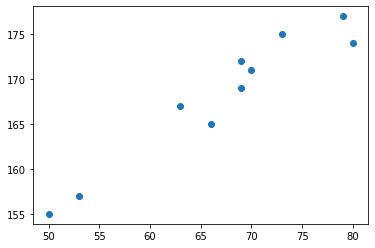

In [4]:
import matplotlib.pyplot as plt

x = df['bb']
y = df['tb']

plt.scatter(x, y)
plt.show()

# Sum of Squared Residual (SSR)

Sebelum mencari fungsi SSR, terlebih dahulu kita cari residu (R) dan data observasi yaitu dengan cara:

\begin{align}
    r = y_t - y_p \label{eq2}\tag{2}
\end{align}

di mana $y_t$ adalah tb asli hasil observasi dan $y_p$ adalah nilai tb berdasarkan prediksi pada fungsi persamaan (1). Tujuan dari RL tidak lain adalah meminimalkan nilai SSR. Adapun fungsi persamaan dari SSR adalah:

\begin{align}
SSR = \sum_{i=1}^{n} (y_{ti} - y_{pi})^2 \label{eq3}\tag{3}
\end{align}

Tidak perlu panik ketika melihat persamaan (\ref{eq3}). Simbol $\sum_{i=1}^{n}$ tidak lain **hanyalah** penyederhanaan dari penjumlahan yang panjang. Misalnya, ada fungsi 

$$
SSR = \sum_{i=1}^{3} (y_{ti} - y_{pi})^2
$$

jika dibedah, maka akan seperti:

$$
SSR = (y_{t1} - y_{p1})^2 + (y_{t2} - y_{p2})^2 + (y_{t3} - y_{p3})^2
$$

sederhana sekali kan?

# Fungsi Optimasi Parameter

Dengan teknik GD, kita bisa mencari fungsi dari parameter $m$ dan $c$ dengan cara meminimalkan fungsi $SSR$.

## Parameter m

Untuk mencari $m$, kita bisa mencari turunan pertama dari $SSR$ terhadap $m$, yaitu:

\begin{align}
\frac{\partial SSR}{\partial m} = -2 \sum_{i=1}^{n} x_i(y_{ti} - mx_i - c) \label{eq4}\tag{4}
\end{align}


## Parameter c

dan $c$, bisa didapat dari:

\begin{align}
\frac{\partial SSR}{\partial c} = -2 \sum_{i=1}^{n} (y_{ti} - mx_i - c) \label{eq5}\tag{5}
\end{align}

# Coding time

Di bagian ini, kita memanfaatkan python untuk mencari nilai $m$ dan $c$ hingga mencapai konvergen. Kode yang dibuat, dipecah menjadi dua fungsi, yaitu fungsi `fit()` dan `predict()` 

## Fungsi Fitting

Kita buat terlebih dulu fungsi `fit()`, yaitu:

In [5]:
def fit(data, epoch=1000, lr=0.00001):
    
    m = 0 # inisialisasi awal m
    c = 0 # inisialisasi awal c
    
    for i in range(epoch):
        sum_dSSR_dc = 0
        sum_dSSR_dm = 0
        
        for x, yt in zip(data.iloc[:,0], data.iloc[:,1]):
        
            dSSR_dc = -2 * (yt - m * x - c)
            dSSR_dm = -2 * x * (yt - m * x - c)
            
            sum_dSSR_dc += dSSR_dc
            sum_dSSR_dm += dSSR_dm
            
        step_m = sum_dSSR_dm * lr
        step_c = sum_dSSR_dc * lr 
        
        m = m - step_m
        c = c - step_c
        
            
    return m,c

## Fungsi Prediksi

Selanjutnya, kita buat fungsi `prediksi()`

In [6]:
def predict(x, m, c):
    
    y = m * x + c
    return y


In [7]:
m, c = fit(df, epoch=1000, lr=0.000001)
x_tes = 64 # membuat data sampel untuk tes
y_prediksi = predict(x_tes, m, c) 
print(y_prediksi)
print(m,c)

158.0507041446001
2.4682754953724446 0.08107244076365137


Dengan hasil nilai parameter yang telah optimal, selain mendapatkan hasil prediksi, kita juga bisa mendapatkan visualisasi dari model RL-nya.  

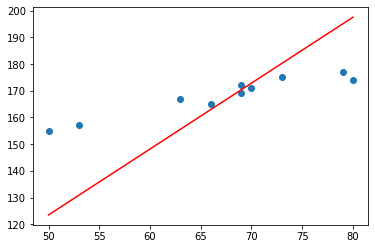

In [9]:
x = df.iloc[:,0]
y = df.iloc[:,1]

yp = m * x + c
plt.scatter(x, y) 
plt.plot(
    [min(x), max(x)], 
    [min(yp), max(yp)], 
    color='red'
)  
plt.show()


# Tugas Praktikum 1

## Deskripsi

Lakukan regresi linier pada dataset https://raw.githubusercontent.com/chasinginfinity/ml-from-scratch/master/02%20Linear%20Regression%20using%20Gradient%20Descent/data.csv

## Identitas dataset



## Penilaian 
1. Program harus dibuat dengan bahasa Jupyter Notebook (10 poin)
1. Harus ada fungsi fit() dengan parameter data, epoch, dan lr. Contoh: fit(data, epoch, lr) (40 poin)
1. Harus ada fungsi prediksi(x, m, c) (30 poin)
1. Munculkan hasil prediksi dengan matplotlib (10 poin)
1. Munculkan nilai m dan c yang paling optimal(10 poin)

## Catatan 
1. Pengumpulan tugas praktikum 1 dikumpulkan di Google Classroom dengan nama file TP1_NIM_Nama_Lengkap_Anda.ipynb
1. Kesalahan penamaan nama dan format file, berakibat pada penolakan Tugas Praktikum 1

# Referensi
[1] A. Ng and K. Soo, Numsense! Data Science for the Layman: No Math Added. Annalyn Ng and Kenneth Soo, 2017.  
[2] G. James, D. Witten, T. Hastie, and R. Tibshirani, An Introduction to Statistical Learning: with Applications in R. Springer New York, 2013.  
[3] I. H. Witten, Data Mining (Fourth Edition). 2017.  
[4] M. Negnevitsky, Artificial Intelligence: A Guide to Intelligent Systems. Addison-Wesley, 2005.  
[5] F. Provost and T. Fawcett, Data Science for Business: What You Need to Know about Data Mining and Data-Analytic Thinking. O’Reilly Media, 2013.  
[6] I. H. Witten, E. Frank, M. A. Hall, and C. Pal, Data Mining: Practical Machine Learning Tools and Techniques. Elsevier Science, 2016.  
[7] M. Yildiz et al., “Elderly trauma: The two years experience of a University-affiliated Emergency Department,” Eur. Rev. Med. Pharmacol. Sci., vol. 16, no. SUPPL. 1, pp. 62–67, 2012.  